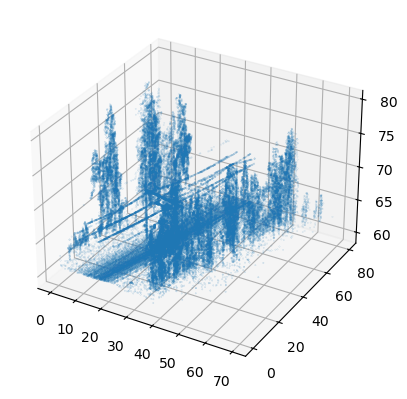

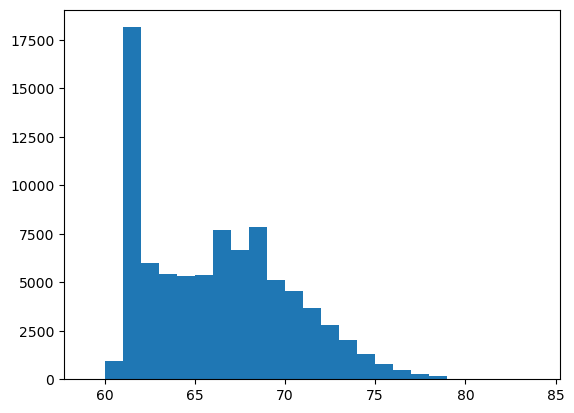

64.23200000000003


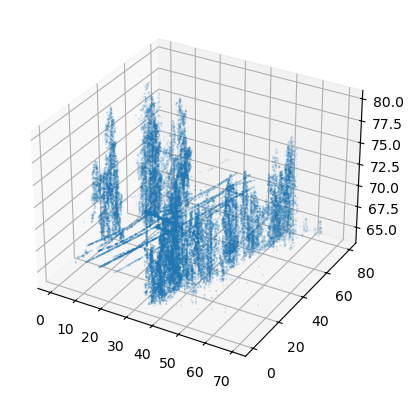

'\nTask 3 (+1)\n\nFind the largest cluster, since that should be the catenary, \nbeware of the noise cluster.\n\nUse the x,y span for the clusters to find the largest cluster\n\nFor both the datasets\nReport min(x), min(y), max(x), max(y) for the catenary cluster in the Readme of your github project\nAdd the plot of the catenary cluster to the readme\n\n'

In [29]:
'''
point cloud data is stored as a 2D matrix
each row has 3 values i.e. the x, y, z value for a point

Project has to be submitted to github in the private folder assigned to you
Readme file should have the numerical values as described in each task
Create a folder to store the images as described in the tasks.

Try to create commits and version for each task.

'''
#%%
import matplotlib
import numpy as np
from scipy.spatial import KDTree
#Caj Rollny: import scipy.stats to calculate mode on np.array
from scipy import stats
#*****
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


#%% utility functions
def show_cloud(points_plt):
    ax = plt.axes(projection='3d')
    ax.scatter(points_plt[:,0], points_plt[:,1], points_plt[:,2], s=0.01)
    plt.show()

def show_scatter(x,y):
    plt.scatter(x, y)
    plt.show()

def get_ground_level(pcd):
    #Caj Rollny: original: return 64
    #calculate ground level: mode + x.y metres (for elimination of vegetation, snow etc)
    m = stats.mode(pcd[:,2])
    #to remove all ground, 3 extra metres was needed:
    return m[0] + 3 #added extra metres to remove all ground.


#%% read file containing point cloud data
#pcd = np.load("dataset1.npy")
pcd = np.load("dataset2.npy")

#debug: print(pcd.shape)
#debug: print(pcd[0])


#%% show downsampled data in external window
# matplotlib qt
# Caj Rollny: plot before removing ground:
show_cloud(pcd)
#show_cloud(pcd[::10]) # keep every 10th point

#%% remove ground plane

'''
Task 1 (3)
find the best value for the ground level
One way to do it is useing a histogram 
np.histogram

update the function get_ground_level() with your changes

For both the datasets
Report the ground level in the readme file in your github project
Add the histogram plots to your project readme
'''
#Caj Rollny: make a histogram based on point cloud and analyze it:
#plot histogram:
fig = plt.Figure(figsize=(10, 10))
plt.hist(pcd[:,2], bins=np.arange(59,85,1)) #np.arange(59,85,1) generates an array with values between 59-85
plt.show()
# Caj Rollny: I iterated thru different bins of z-values and the concentration lie between 60 and 80
# the mode of the z-points in the dataset should be the ground:
# print("Mean: ", pcd[:,2].mean())
# m = stats.mode(pcd[:,2])
# print(m[0])
# Mode on dataset 1 was 61.27000, I'll use this as ground level
# Mode on dataset 2 was 61.23200 

est_ground_level = get_ground_level(pcd)
print(est_ground_level)

pcd_above_ground = pcd[pcd[:,2] > est_ground_level] 
#%%
pcd_above_ground.shape

#%% side view
show_cloud(pcd_above_ground)





#%%
'''
Task 2 (+1)

Find an optimized value for eps.
Plot the elbow and extract the optimal value from the plot
Apply DBSCAN again with the new eps value and confirm visually that clusters are proper

https://www.analyticsvidhya.com/blog/2020/09/how-dbscan-clustering-works/
https://machinelearningknowledge.ai/tutorial-for-dbscan-clustering-in-python-sklearn/

For both the datasets
Report the optimal value of eps in the Readme to your github project
Add the elbow plots to your github project Readme
Add the cluster plots to your github project Readme
'''

'''
# %%
unoptimal_eps = 10
# find the elbow
clustering = DBSCAN(eps = unoptimal_eps, min_samples=5).fit(pcd_above_ground)

#%%
clusters = len(set(clustering.labels_)) - (1 if -1 in clustering.labels_ else 0)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, clusters)]

# %%
# Plotting resulting clusters
plt.figure(figsize=(10,10))
plt.scatter(pcd_above_ground[:,0], 
            pcd_above_ground[:,1],
            c=clustering.labels_,
            cmap=matplotlib.colors.ListedColormap(colors),
            s=2)


plt.title('DBSCAN: %d clusters' % clusters,fontsize=20)
plt.xlabel('x axis',fontsize=14)
plt.ylabel('y axis',fontsize=14)
plt.show()

#%%
''' 
'''
Task 3 (+1)

Find the largest cluster, since that should be the catenary, 
beware of the noise cluster.

Use the x,y span for the clusters to find the largest cluster

For both the datasets
Report min(x), min(y), max(x), max(y) for the catenary cluster in the Readme of your github project
Add the plot of the catenary cluster to the readme

'''
